# Maine Election Analysis

## Import Libraries

In [3]:
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_2024 = pd.read_csv("maine_2024_polling_backtest.csv")
data_2020 = pd.read_csv("maine_2020_polling_backtest.csv")
data_2018 = pd.read_csv("maine_2018_polling_backtest.csv")
data_2014 = pd.read_csv("maine_2014_polling_backtest.csv")

## Backtest data from Maine's 2014 - 2024 polling data, end result

2024 Polling Data: DEM: 7%, REP: 35%, THIRD: 50%
2020 Polling Data: DEM: 46%, REP: 41%, THIRD: 13%
2018 Polling Data: DEM: 50%, REP: 37%, THIRD: 13%
2014 Polling Data: DEM: 33%, REP: 57%, THIRD: 10%


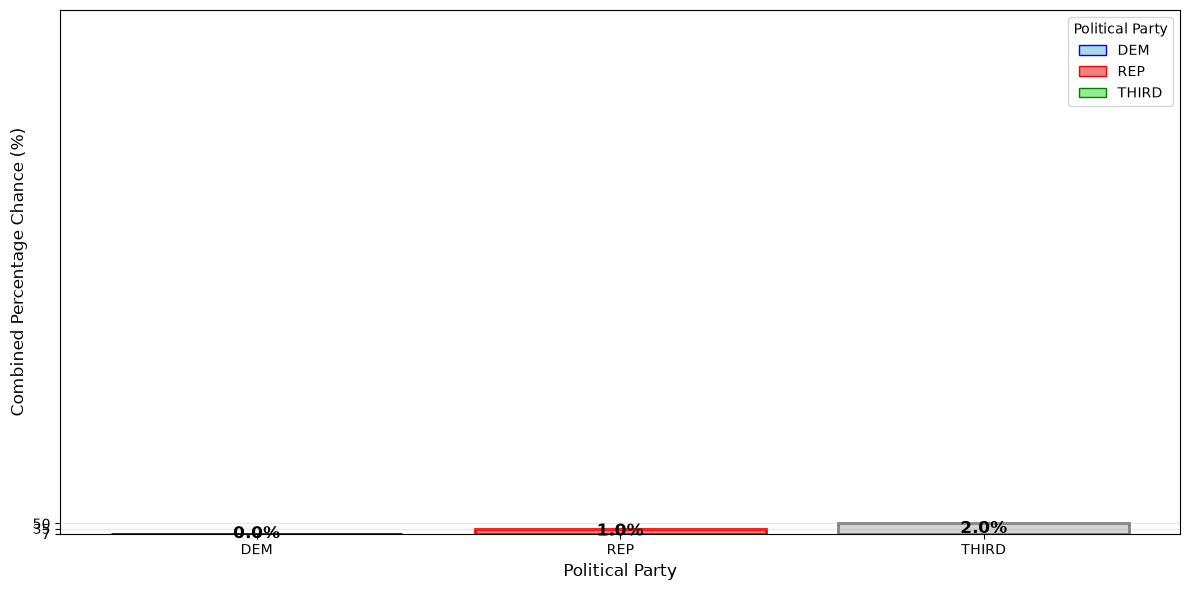

In [4]:
# Retrieve end result from 2024 polling data
democrat_data_2024 = data_2024.iloc[1, 4]
republican_data_2024 = data_2024.iloc[2, 4]
third_party_data_2024 = data_2024.iloc[3, 4]

# Retrieve end result from 2020 polling data
democrat_data_2020 = data_2020.iloc[1, 4]
republican_data_2020 = data_2020.iloc[2, 4]
third_party_data_2020 = data_2020.iloc[3, 4]

# Retrieve end result from 2018 polling data
democrat_data_2018 = data_2018.iloc[1, 4]
republican_data_2018 = data_2018.iloc[2, 4]
third_party_data_2018 = data_2018.iloc[3, 4]

# Retrieve end result from 2014 polling data
democrat_data_2014 = data_2014.iloc[1, 4]
republican_data_2014 = data_2014.iloc[2, 4]
third_party_data_2014 = data_2014.iloc[3, 4]

print(f"2024 Polling Data: DEM: {democrat_data_2024}%, REP: {republican_data_2024}%, THIRD: {third_party_data_2024}%")
print(f"2020 Polling Data: DEM: {democrat_data_2020}%, REP: {republican_data_2020}%, THIRD: {third_party_data_2020}%")
print(f"2018 Polling Data: DEM: {democrat_data_2018}%, REP: {republican_data_2018}%, THIRD: {third_party_data_2018}%")
print(f"2014 Polling Data: DEM: {democrat_data_2014}%, REP: {republican_data_2014}%, THIRD: {third_party_data_2014}%")

# Define colors for each party (lighter versions)
party_colors = {"DEM": "lightblue", "REP": "lightcoral", "NONE": "lightgreen"}
party_edge_colors = {"DEM": "blue", "REP": "red", "NONE": "green"}

# Legend elements
legend_elements = [
    Patch(facecolor="lightblue", edgecolor="blue", label="DEM"),
    Patch(facecolor="lightcoral", edgecolor="red", label="REP"),
    Patch(
        facecolor="lightgreen", edgecolor="green", label="THIRD"
    ),
]

# Store the end results in a list for plotting
parties = ["DEM", "REP", "THIRD"]
percentages = [democrat_data_2024, republican_data_2024, third_party_data_2024]

# Create the bar chart
plt.figure(figsize=(12, 6))

# Create bars with lighter colors and error bars
bars = []
for i, party in enumerate(parties):
    color = party_colors.get(party, "lightgray")
    edge_color = party_edge_colors.get(party, "gray")
    percentage = percentages[i]

    # Create bar with lighter fill and darker edge
    bar = plt.bar(
        i,
        percentage,
        color=color,
        edgecolor=edge_color,
        linewidth=2,
        capsize=6,
        error_kw={"linewidth": 2.5, "ecolor": edge_color, "capsize": 6},
    )
    bars.append(bar)

# Set y-axis limits (0 to 100 since it's a percentage)
plt.ylim(0, 100)

# Set x-axis tick positions and labels
plt.xticks(ticks=[0, 1, 2], labels=parties)

# Add percentage labels INSIDE the bars
for i, bar in enumerate(bars):
    height = bar[0].get_height()
    # Place text in the middle of each bar
    plt.text(bar[0].get_x() + bar[0].get_width()/2., height/2, 
             f'{height}%', ha='center', va='center', 
             fontweight='bold', fontsize=12, color='black')

# Labels and title
plt.xlabel("Political Party", fontsize=12)
plt.ylabel("Combined Percentage Chance (%)", fontsize=12)

# Add grid
plt.grid(axis="y", alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title="Political Party", loc="upper right")

plt.tight_layout()
plt.savefig(f"_static/images/maine_backtest_data_.png", dpi=300, bbox_inches="tight")
plt.show()